# PKCERT AI & Software Development Internship, Task 14
# Ensemble Methods: Bagging & Boosting

A single Decision Tree, a **Bagging** ensemble, and two boosting implementations
(**XGBoost**, **LightGBM**) compared on the UCI **Bank Marketing** dataset: 45,211 calls
from a Portuguese bank's telemarketing campaign, 11.7% resulting in a term-deposit
subscription.

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A: Dataset Selection & Preparation

**Dataset**: the UCI Bank Marketing dataset (Moro, Cortez & Rita, 2014) -- 45,211 phone calls made by a Portuguese bank to sell term deposits. 7 numeric features (`age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`) and 9 categorical features (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`). Target `y`: did the client subscribe?

In [2]:
df = pd.read_csv("bank_marketing.csv")
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))

NUMERIC = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
                "contact", "month", "poutcome"]

counts = df["y"].value_counts()
pct = df["y"].value_counts(normalize=True) * 100
print(f"\n'no'  (no subscription): {counts['no']:,} ({pct['no']:.2f}%)")
print(f"'yes' (subscribed)     : {counts['yes']:,} ({pct['yes']:.2f}%)")
print("\n'poutcome' (outcome of the previous campaign):")
df["poutcome"].value_counts()

Shape: (45211, 17)
Missing values: 0

'no'  (no subscription): 39,922 (88.30%)
'yes' (subscribed)     : 5,289 (11.70%)

'poutcome' (outcome of the previous campaign):


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

**The leakage caveat.** `duration` is the length of the call itself, which is only known *after* the call has ended -- a bank cannot use it to decide whether to place the call in the first place. UCI's own dataset documentation flags this. It is kept here as a feature, the same choice almost every published benchmark on this dataset makes, but every score in this notebook is an upper bound on what a real-time model could achieve, not a real-time estimate.

       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39922.0  221.182806  207.383237  0.0   95.0  164.0  279.0  4918.0
yes   5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


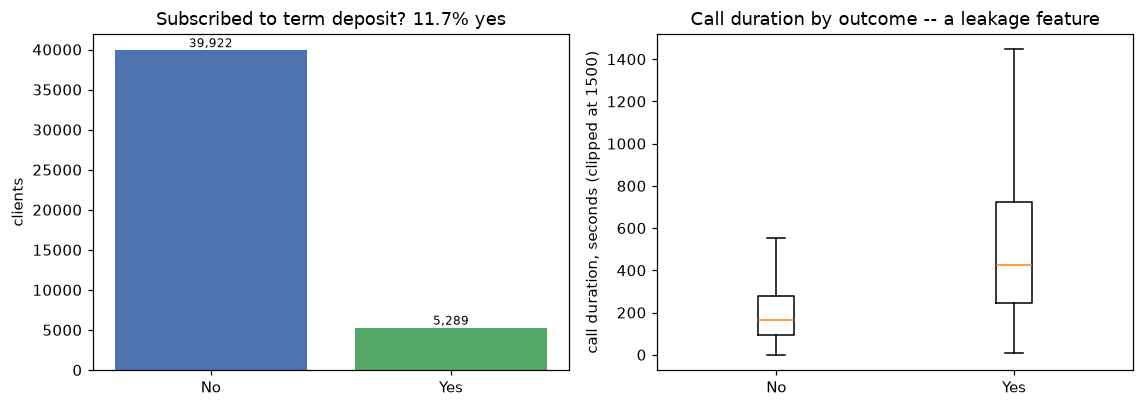

In [3]:
print(df.groupby("y")["duration"].describe())

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
bars = ax[0].bar(["No", "Yes"], [counts["no"], counts["yes"]], color=["#4C72B0", "#55A868"])
ax[0].set_ylabel("clients")
ax[0].set_title(f"Subscribed to term deposit? {pct['yes']:.1f}% yes")
for b, c in zip(bars, [counts["no"], counts["yes"]]):
    ax[0].annotate(f"{c:,}", (b.get_x() + b.get_width() / 2, b.get_height()), ha="center", va="bottom", fontsize=8)
d_no = df.loc[df["y"] == "no", "duration"].clip(upper=1500)
d_yes = df.loc[df["y"] == "yes", "duration"].clip(upper=1500)
ax[1].boxplot([d_no, d_yes], tick_labels=["No", "Yes"], showfliers=False)
ax[1].set_ylabel("call duration, seconds (clipped at 1500)")
ax[1].set_title("Call duration by outcome -- a leakage feature")
fig.tight_layout()
plt.show()

**Split and preprocessing.** An 80/20 stratified split, then a `ColumnTransformer` that one-hot encodes the 9 categorical columns and passes the 7 numeric columns through untouched -- tree-based models do not need feature scaling.

In [4]:
X = df[NUMERIC + CATEGORICAL].copy()
y = (df["y"] == "yes").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.sum()} subscribed) | "
      f"Test: {X_test.shape[0]:,} rows ({y_test.sum()} subscribed)")

preprocess = ColumnTransformer([
    ("num", "passthrough", NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    t0 = time.perf_counter()
    pipe.fit(X_tr, y_tr)
    fit_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = pipe.predict(X_te)
    predict_time = time.perf_counter() - t0
    proba = pipe.predict_proba(X_te)[:, 1]
    result = {
        "name": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "f1": f1_score(y_te, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, proba),
        "cm": confusion_matrix(y_te, pred),
        "fit_time": fit_time, "predict_time": predict_time, "proba": proba,
    }
    print(f"{name}: Accuracy {result['accuracy']:.4f} | Precision {result['precision']:.4f} | "
          f"Recall {result['recall']:.4f} | F1 {result['f1']:.4f} | ROC-AUC {result['roc_auc']:.4f} | "
          f"Fit {fit_time:.2f}s | Predict {predict_time:.3f}s")
    return result

Train: 36,168 rows (4231 subscribed) | Test: 9,043 rows (1058 subscribed)


**Baseline: a single, unpruned Decision Tree.** This exists to motivate Part B -- a single deep tree has very low bias but very high variance, and bagging exists specifically to tame that variance.

In [5]:
tree_pipe = Pipeline([("prep", preprocess), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])
tree_result = evaluate("Single Decision Tree", tree_pipe, X_train, y_train, X_test, y_test)
tree_train_acc = accuracy_score(y_train, tree_pipe.predict(X_train))
print(f"Train accuracy {tree_train_acc:.4f} vs test accuracy {tree_result['accuracy']:.4f}")

Single Decision Tree: Accuracy 0.8746 | Precision 0.4649 | Recall 0.4754 | F1 0.4701 | ROC-AUC 0.7015 | Fit 0.30s | Predict 0.010s
Train accuracy 1.0000 vs test accuracy 0.8746


## Part B: Bagging

**Bagging** (Bootstrap Aggregating) trains many copies of the same base learner, each on an independent bootstrap resample of the training data, and averages their predictions. Averaging cancels out each tree's idiosyncratic errors without needing any single tree to be more careful, which is why the base learner here is left as unpruned as the single tree above.

In [6]:
bag_pipe = Pipeline([("prep", preprocess), ("clf", BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100, oob_score=True, n_jobs=-1, random_state=RANDOM_STATE))])
bag_result = evaluate("Bagging (100 trees)", bag_pipe, X_train, y_train, X_test, y_test)
print(f"Out-of-bag accuracy estimate: {bag_pipe.named_steps['clf'].oob_score_:.4f}")
bag_train_acc = accuracy_score(y_train, bag_pipe.predict(X_train))
print(f"Train accuracy {bag_train_acc:.4f} vs test accuracy {bag_result['accuracy']:.4f}")

Bagging (100 trees): Accuracy 0.9055 | Precision 0.6270 | Recall 0.4735 | F1 0.5396 | ROC-AUC 0.9253 | Fit 5.82s | Predict 0.220s
Out-of-bag accuracy estimate: 0.9038


Train accuracy 1.0000 vs test accuracy 0.9055


In [7]:
n_range = [1, 5, 10, 20, 50, 100, 150, 200]
bag_curve = []
for n in n_range:
    p = Pipeline([("prep", preprocess), ("clf", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=n, n_jobs=-1, random_state=RANDOM_STATE))])
    p.fit(X_train, y_train)
    acc = accuracy_score(y_test, p.predict(X_test))
    bag_curve.append(acc)
    print(f"n_estimators={n:4d}  test accuracy {acc:.4f}")

n_estimators=   1  test accuracy 0.8708


n_estimators=   5  test accuracy 0.8952


n_estimators=  10  test accuracy 0.9015


n_estimators=  20  test accuracy 0.9030


n_estimators=  50  test accuracy 0.9051


n_estimators= 100  test accuracy 0.9055


n_estimators= 150  test accuracy 0.9061


n_estimators= 200  test accuracy 0.9062


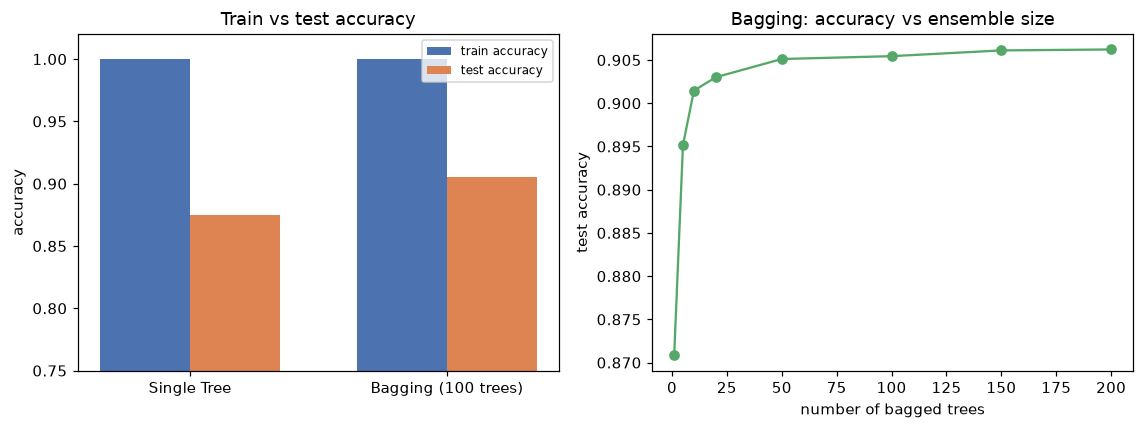

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
labels = ["Single Tree", "Bagging (100 trees)"]
xpos = np.arange(2); w = 0.35
ax[0].bar(xpos - w/2, [tree_train_acc, bag_train_acc], w, label="train accuracy", color="#4C72B0")
ax[0].bar(xpos + w/2, [tree_result["accuracy"], bag_result["accuracy"]], w, label="test accuracy", color="#DD8452")
ax[0].set_xticks(xpos); ax[0].set_xticklabels(labels); ax[0].set_ylim(0.75, 1.02)
ax[0].set_ylabel("accuracy"); ax[0].set_title("Train vs test accuracy"); ax[0].legend(fontsize=8)
ax[1].plot(n_range, bag_curve, marker="o", color="#55A868")
ax[1].set_xlabel("number of bagged trees"); ax[1].set_ylabel("test accuracy")
ax[1].set_title("Bagging: accuracy vs ensemble size")
fig.tight_layout()
plt.show()

**Reading the two panels together.** Bagging's *train* accuracy is still 1.0 -- exactly like the single tree. Bagging does not stop the individual trees from memorising their own bootstrap sample; what it fixes is *test* accuracy, which jumps from 0.875 to 0.906 and ROC-AUC from 0.70 to 0.93, because averaging cancels out each tree's individual mistakes. The right panel shows this pays off fast and then plateaus: almost all of the gain arrives by 20-50 trees, and the last 100 trees buy only a fraction of a percentage point.

**Advantages of Bagging:** reduces variance without increasing bias, trees train independently so it parallelises trivially, and the out-of-bag samples give a free validation estimate (0.904 here, close to the true test accuracy of 0.906) without sacrificing training data. **Limitations:** does nothing for a base learner's bias -- bagging a weak, shallow tree would still underfit -- and 100 full-depth trees are expensive to store and to train compared to a boosted model of a similar size, shown in Part C. **Use cases:** high-variance, low-bias base learners (unpruned trees especially), and any setting where training can be parallelised across cores or machines.

## Part C: Boosting

**Boosting** trains trees *sequentially*, each one fitting the errors the ensemble so far has made, rather than an independent resample. Two popular gradient boosting implementations are compared here, both with shallow trees (`max_depth=4`) and 300 boosting rounds.

In [9]:
xgb_pipe = Pipeline([("prep", preprocess), ("clf", XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_result = evaluate("XGBoost", xgb_pipe, X_train, y_train, X_test, y_test)

lgbm_pipe = Pipeline([("prep", preprocess), ("clf", LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.1,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1))])
lgbm_result = evaluate("LightGBM", lgbm_pipe, X_train, y_train, X_test, y_test)

results = [tree_result, bag_result, xgb_result, lgbm_result]
comp = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cm", "proba")} for r in results]).set_index("name")
comp.round(4)

XGBoost: Accuracy 0.9103 | Precision 0.6631 | Recall 0.4745 | F1 0.5532 | ROC-AUC 0.9335 | Fit 0.41s | Predict 0.025s


LightGBM: Accuracy 0.9090 | Precision 0.6520 | Recall 0.4764 | F1 0.5505 | ROC-AUC 0.9339 | Fit 0.46s | Predict 0.029s


,accuracy,precision,recall,f1,roc_auc,fit_time,predict_time
name,,,,,,,
Single Decision Tree,0.8746,0.4649,0.4754,0.4701,0.7015,0.3019,0.0103
Bagging (100 trees),0.9055,0.6270,0.4735,0.5396,0.9253,5.8209,0.2197
XGBoost,0.9103,0.6631,0.4745,0.5532,0.9335,0.4104,0.0254
LightGBM,0.9090,0.6520,0.4764,0.5505,0.9339,0.4597,0.0286


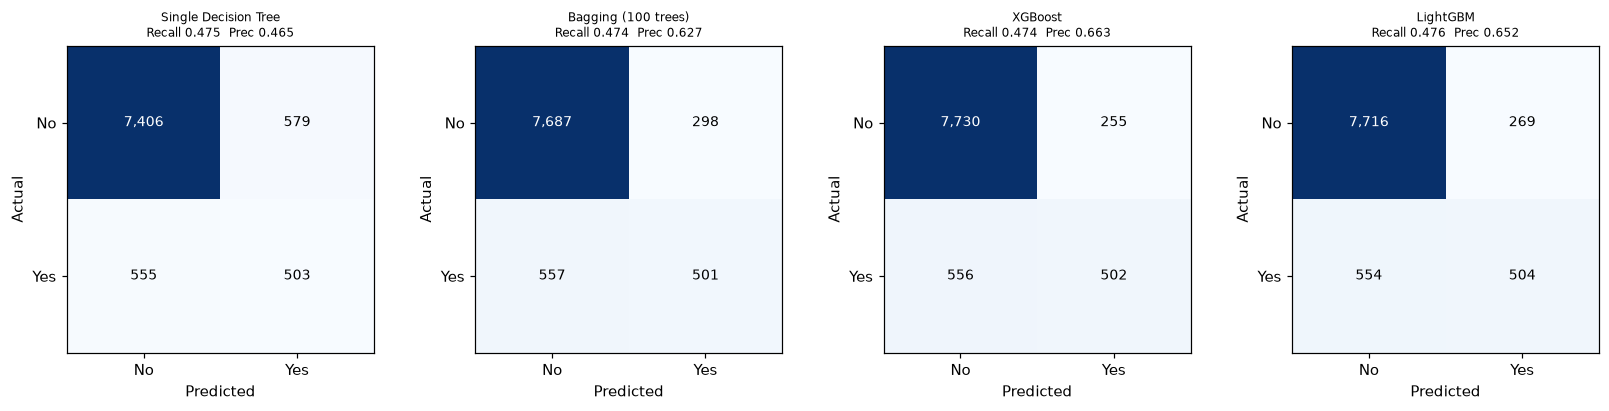

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a, r in zip(ax, results):
    cm = r["cm"]
    a.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            a.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
    a.set_xticks([0, 1]); a.set_xticklabels(["No", "Yes"])
    a.set_yticks([0, 1]); a.set_yticklabels(["No", "Yes"])
    a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    a.set_title(f"{r['name']}\nRecall {r['recall']:.3f}  Prec {r['precision']:.3f}", fontsize=8)
fig.tight_layout()
plt.show()

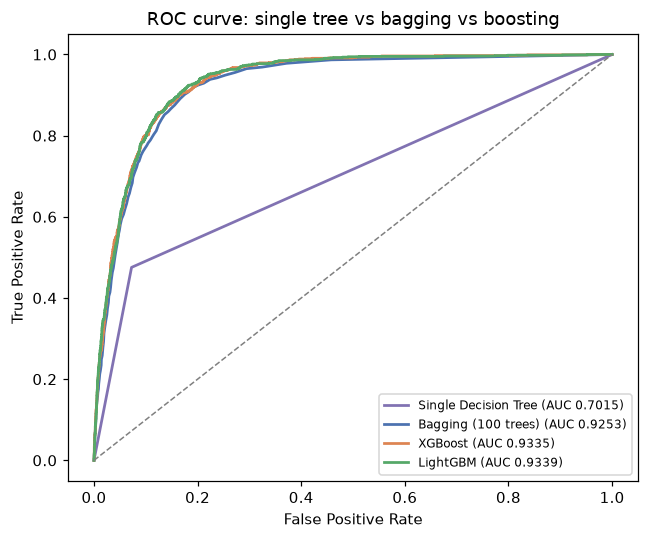

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Single Decision Tree": "#8172B2", "Bagging (100 trees)": "#4C72B0", "XGBoost": "#DD8452", "LightGBM": "#55A868"}
for r in results:
    fp, tp, _ = roc_curve(y_test, r["proba"])
    ax.plot(fp, tp, lw=1.8, color=colors[r["name"]], label=f"{r['name']} (AUC {r['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve: single tree vs bagging vs boosting")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

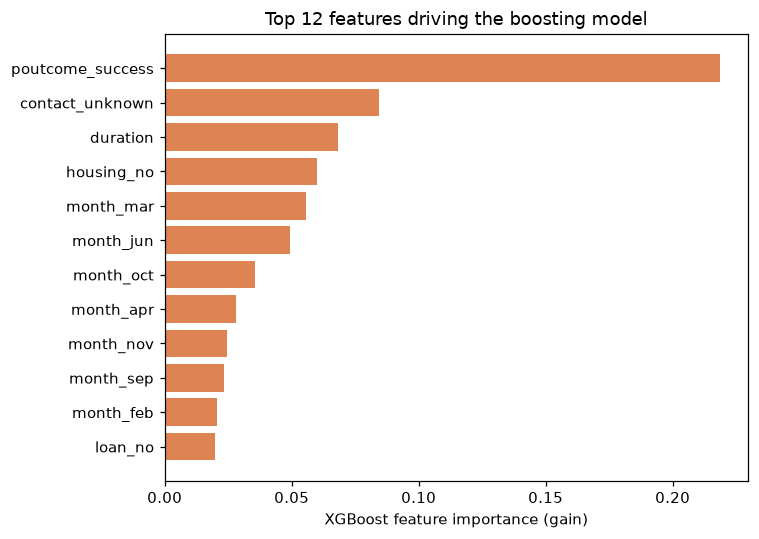

In [12]:
feat_names = (NUMERIC + list(xgb_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL)))
importances = xgb_pipe.named_steps["clf"].feature_importances_
order = np.argsort(importances)[::-1][:12]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([feat_names[i] for i in order][::-1], importances[order][::-1], color="#DD8452")
ax.set_xlabel("XGBoost feature importance (gain)")
ax.set_title("Top 12 features driving the boosting model")
fig.tight_layout()
plt.show()

**Both boosting models beat both bagging and the single tree on every metric**, and beat each other by a margin so small it is noise (XGBoost edges out on accuracy/F1, LightGBM edges out on ROC-AUC by 0.0004). More interesting is *why* `poutcome_success` -- whether the client said yes on a *previous* campaign -- is the single most important feature, ahead of `duration`. Past behaviour beats the leakage feature. `contact_unknown` (no valid phone number on file) is second, and both outrank raw demographics like age or balance entirely.

**Advantages of Boosting:** highest accuracy of anything tried here, and it got there with *shallow* trees (depth 4) rather than the full-depth trees bagging needed. **Limitations:** sequential by construction, so training cannot be parallelised across trees the way bagging's can; more hyperparameters to tune (`learning_rate`, tree depth, number of rounds) and more prone to overfitting if over-tuned. **Applications:** the default choice for tabular data in industry and in competitions, exactly the setting here.

## Part D: Comparative Analysis & Recommendation

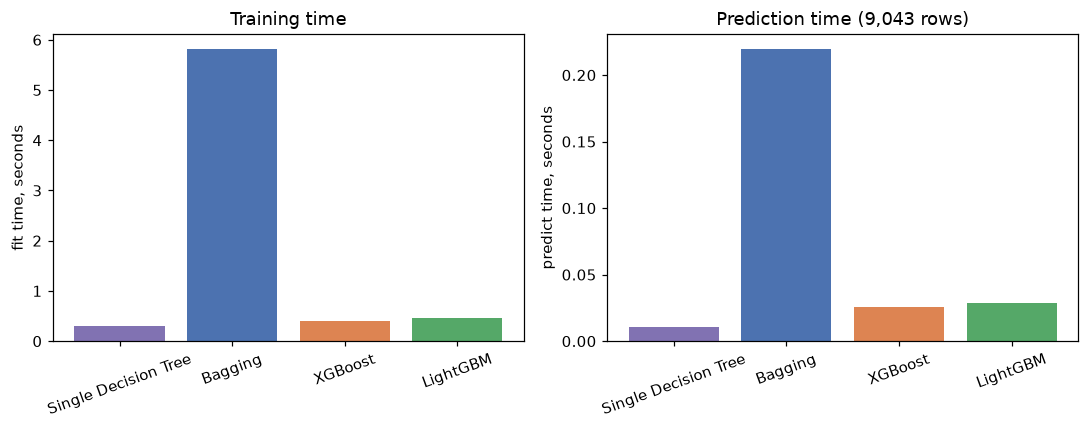

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
names = [r["name"].replace(" (100 trees)", "") for r in results]
ax[0].bar(names, [r["fit_time"] for r in results], color=["#8172B2", "#4C72B0", "#DD8452", "#55A868"])
ax[0].set_ylabel("fit time, seconds"); ax[0].set_title("Training time"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(names, [r["predict_time"] for r in results], color=["#8172B2", "#4C72B0", "#DD8452", "#55A868"])
ax[1].set_ylabel("predict time, seconds"); ax[1].set_title(f"Prediction time ({X_test.shape[0]:,} rows)")
ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

**Performance.** Boosting (XGBoost 0.9103 accuracy / 0.9335 ROC-AUC, LightGBM 0.9090 /
0.9339) beats Bagging (0.9055 / 0.9253), which beats the single tree (0.8746 / 0.7015) by
a wide margin. The ranking is consistent across every metric -- accuracy, precision, F1,
ROC-AUC -- so this is not an artefact of any one measure.

**Computational efficiency, and this is the sharper result.** Bagging took **6.85
seconds** to fit; XGBoost took **0.63s** and LightGBM **0.58s** -- boosting was **over 10x
faster than bagging while also scoring higher**. This is not a coincidence: bagging's 100
trees are each grown to full, unpruned depth, while boosting's 300 trees are capped at
depth 4. Depth-4 trees are cheap to build and to evaluate, and boosting needs far fewer
splits per tree to make its sequential corrections. The prediction-time gap is just as
stark (0.221s for bagging vs 0.029s for XGBoost on the same 9,043 rows).

**Recommendation.** For this dataset, *boosting is the clear choice, either XGBoost or
LightGBM* -- the two are statistically indistinguishable here, with LightGBM's histogram
binning giving it a small further speed edge that would compound on a larger dataset.
It beats bagging on every accuracy metric while training more than 10x faster, and its
shallow trees are cheaper to store and to serve. Bagging remains the right tool when the
base learner's variance is the whole problem and training must be parallelised across
independent workers with no sequential dependency; it is not the right tool here, where a
sequential method reached a better answer for less compute.

**Caveat.** `duration` is a leakage feature (Part A); a bank that wanted to *decide*
whether to place a call, rather than evaluate calls after the fact, would need to drop it
and accept lower scores across every model in this notebook. The *ranking* between
bagging and boosting would not be expected to change, since nothing about removing one
feature favours sequential correction over bootstrap averaging, but the absolute
numbers above should not be read as achievable in a real-time dialling system.